# Question 3: Demystifying Transformers – Building a Tiny Language Model

## Part A

### 3A.1.a

If $q$ and $k$ are random vectors whose entries are drawn from a distribution with mean 0 and variance 1, the variance of their dot product is going to be equal to the dimension and the mean is going to be 0. We know $q.k = \sum_i^{d_k} q_i . k_i$. Hence, 


$\mathbb{E}[q_i.k_i] = \mathbb{E}[q_i]\,\mathbb{E}[k_i] = 0$

$Var(q_i.k_i) = \mathbb{E}[q_i^2.k_i^2] - 0^2 = \mathbb{E}[q_i^2]\,\mathbb{E}[k_i^2] = 1$

Hence, 

$\mathbb{E}[q.k] = 0$
$Var[q.k] = \sum_i^{d_k} Var(q_i.k_i) = d_k$

If a query and key pair have large variance product, it would mean their values can reach very high numbers. The softmax over high attention scores is usually very unevenly distributed, with majority of the probability assigned to one or two tokens. When the values in softmax is very high, the gradients nears zero and no learning occurs in the network. Due to avoid getting such high probabilities, the scores are divided by a the term $\sqrt d_k$. On division the variance becomes one instead of $d_k$. 


### 3A.1.b

If we ommitted the scaling term, the gradient of softmax would tend to near zero, due to the reasons discussed above. 

In [ ]:
# for 3.A.2
import torch

matrix = torch.ones(4, 4)
ut = torch.triu(matrix, diagonal=1)
torch.masked_fill(ut, ut == 1, float('-inf'))

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

### 3A.2.a

tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])


### 3A.2.b

This is important in left to right language models as the main task for these models is to predict the next word using the context provided by the previous words. The main reason is how autoregressive model, an specifically autoregressive language models are formulated. They are formulated as $p(y_1, y_2, \dots, y_t) = \prod_t^T p(y_t| y_{<t})$. Firstly, this suggests that the language generation is modelled with the key constraint of the generation at a time step only depending upon the previous timesteps and not the later time steps. Secondly, it is also enforced because of parallel training and teacher forcing. If we did not do parallel training, rather trained the model sequentially at each step we would only compuyte the attention masks of the time step $t$ and prior time steps as the future time steps would not be in training. However due to parallel training the future tokens are going to be input and are goijng ot be input as ground truth due to teacher forcing. Due to this we need to avoid the future ground truth token and need causal masks to avoid them in the attenion score computation. 

We do not need them in BERT style models as the pretraining objective for them is bidirectional and are used for specific tasks. They were built as a single language representation for varied NLP tasks and used the whole input as a context. Due to this, at a particular time step the tokens from both the previous and future time steps are going to be used and we do not causal masking. 

### 3A.3.a

$PE(pos, 2i) = sin(pos/10000^{2i/d_model})$
$PE(pos, 2i+1) = cos(pos/10000^{2i/d_model})$

### 3A.3.b

Advantage: Learned positional embeddings are trainable, so the model can adapt positional representations to the statistics of the dataset and task instead of relying on a fixed hand-designed pattern. This can let the model learn position information that is more useful for the training distribution than sinusoidal embeddings.

Advantage: Learned positional embeddings are trainable so they allow the model to adapt posotional representations to the distribution of data it is trained on. 

Disadvantage: In cases where training data for low resource languages are limited, positional encodings can provide meaningful position knowledge for autoregressive language modelling. Due to the limited scale the positional embeddings may not learn meaningful embeddings. Also learned embeddings cannot generalise to sequence length not seen in training. 

### 3A.4.a

The issue with Batch Norm when sequences in batch are padded to different true lengths is that the batch statistics in each iteration depend on the number of padding tokens, which may change for different lengths. For a small true length, the batch statistic can be completely distorted by padding tokens and the normalisation will be heavily batch dependent which we ironically want to avoid. Padded tokens are fillers to ensure data loading occurs with tensors of equal size, and they are masked during training. They also do not hold any semantic meaning, so they would not add anything meaningful to the batch statistic. Hence we require LayerNorm that normalises each token across its feature dimensions, rather than across the batch. This way the token is independent of any other token and hence there would not be any issues with the sequence length.

### 3A.4.b





### 3A.5.a

For each head, the dimension is $d_{model}/n_{heads} = 64/4 = 16$

### 3A.5.b

Multi head attention is more expressive than single head attention as it provides the model more capacity to represent concepts. What single head does is provides a single ranking/attention score amongst the tokens, representing which token is most important for the concept the model is learning at that layer/part of the model. However with multiple heads, we can represent multiple concepts on the account of each head calculating the normalised score(softmax score after calculating similarity scores amongst the tokens in the QKV projection space). 

In [1]:
# ============================================================
# CELL 1: Imports, seeds, device
# ============================================================
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# CELL 2: Load corpus and create character-level tokenizer
# ============================================================
with open("corpus.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Corpus length:", len(text))

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join([idx_to_char[i] for i in ids])

data = torch.tensor(encode(text), dtype=torch.long)

split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

print("Vocab size:", vocab_size)
print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

context_len = 128
batch_size = 64

def get_batch(split="train"):
    source = train_data if split == "train" else val_data
    ix = torch.randint(0, len(source) - context_len - 1, (batch_size,))
    x = torch.stack([source[i:i+context_len] for i in ix])
    y = torch.stack([source[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

Corpus length: 5458195
Vocab size: 91
Train tokens: 4912375
Val tokens: 545820


In [3]:
# ============================================================
# CELL 3: 3B.1 Build the Transformer
# ============================================================
class DecoderBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, hidden_dim=256, dropout=0.1, norm_type="pre"):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.norm_type = norm_type

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn1 = nn.Linear(d_model, hidden_dim)
        self.ffn2 = nn.Linear(hidden_dim, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.ffn_dropout = nn.Dropout(dropout)

        self.last_attn = None

    def self_attention(self, x):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        self.last_attn = attn.detach().cpu()

        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        return out

    def ffn(self, x):
        x = self.ffn1(x)
        x = F.gelu(x)
        x = self.ffn2(x)
        x = self.ffn_dropout(x)
        return x

    def forward(self, x):
        if self.norm_type == "pre":
            x = x + self.self_attention(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
        else:
            x = self.norm1(x + self.self_attention(x))
            x = self.norm2(x + self.ffn(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        n_heads=4,
        n_layers=3,
        context_len=128,
        hidden_dim=256,
        dropout=0.1,
        norm_type="pre",
    ):
        super().__init__()

        self.context_len = context_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                hidden_dim=hidden_dim,
                dropout=dropout,
                norm_type=norm_type,
            )
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model) if norm_type == "pre" else nn.Identity()
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        B, T = x.shape
        assert T <= self.context_len, "Sequence length exceeds context window"

        pos = torch.arange(T, device=x.device)
        tok = self.token_emb(x)
        pos = self.pos_emb(pos)[None, :, :]
        x = self.drop(tok + pos)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(B * T, -1), targets.reshape(B * T))

        return logits, loss


model_pre = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="pre",
).to(device)

param_count = sum(p.numel() for p in model_pre.parameters())
print("Total parameter count:", param_count)

Total parameter count: 170011


step    1 | train loss 4.5921 | val loss 4.5958
step  200 | train loss 2.7638 | val loss 2.7796
step  400 | train loss 2.5560 | val loss 2.5729
step  600 | train loss 2.4772 | val loss 2.4928
step  800 | train loss 2.4107 | val loss 2.4264
step 1000 | train loss 2.3552 | val loss 2.3773
step 1200 | train loss 2.3118 | val loss 2.3201
step 1400 | train loss 2.2605 | val loss 2.2758
step 1600 | train loss 2.2204 | val loss 2.2306
step 1800 | train loss 2.1757 | val loss 2.1889
step 2000 | train loss 2.1487 | val loss 2.1553
step 2200 | train loss 2.1194 | val loss 2.1356
step 2400 | train loss 2.0913 | val loss 2.1059
step 2600 | train loss 2.0626 | val loss 2.0744
step 2800 | train loss 2.0447 | val loss 2.0502
step 3000 | train loss 2.0230 | val loss 2.0257
step 3200 | train loss 2.0087 | val loss 2.0054
step 3400 | train loss 1.9821 | val loss 1.9958
step 3600 | train loss 1.9665 | val loss 1.9734
step 3800 | train loss 1.9529 | val loss 1.9657
step 4000 | train loss 1.9301 | val loss

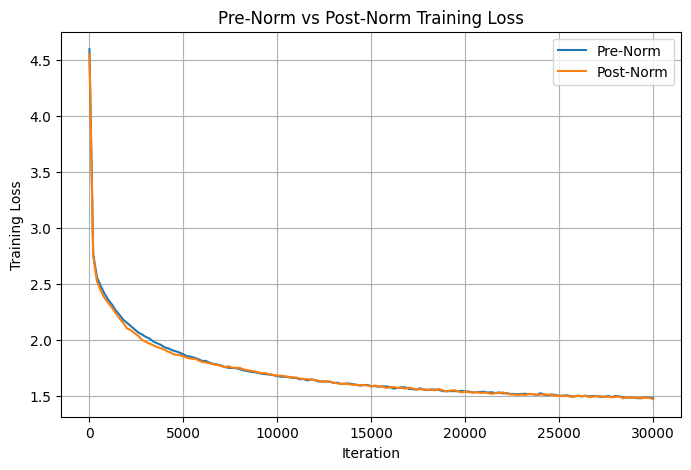

In [4]:
# ============================================================
# CELL 4: 3B.2 Pre-Norm vs Post-Norm training comparison
# ============================================================
@torch.no_grad()
def estimate_loss(model, eval_iters=100):
    model.eval()
    losses = {}
    for split in ["train", "val"]:
        split_losses = []
        for _ in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            split_losses.append(loss.item())
        losses[split] = sum(split_losses) / len(split_losses)
    model.train()
    return losses


def train_model(model, max_iters=30000, lr=3e-4, eval_interval=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_curve = []
    val_curve = []
    eval_steps = []

    model.train()
    for step in range(1, max_iters + 1):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            losses = estimate_loss(model, eval_iters=50)
            train_curve.append(losses["train"])
            val_curve.append(losses["val"])
            eval_steps.append(step)
            print(
                f"step {step:4d} | "
                f"train loss {losses['train']:.4f} | "
                f"val loss {losses['val']:.4f}"
            )

    return {
        "model": model,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "eval_steps": eval_steps,
    }


model_pre = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="pre",
).to(device)

model_post = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="post",
).to(device)

pre_stats = train_model(model_pre, max_iters=30000, lr=3e-4, eval_interval=200)
post_stats = train_model(model_post, max_iters=30000, lr=3e-4, eval_interval=200)

plt.figure(figsize=(8, 5))
plt.plot(pre_stats["eval_steps"], pre_stats["train_curve"], label="Pre-Norm")
plt.plot(post_stats["eval_steps"], post_stats["train_curve"], label="Post-Norm")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Pre-Norm vs Post-Norm Training Loss")
plt.legend()
plt.grid(True)
plt.show()

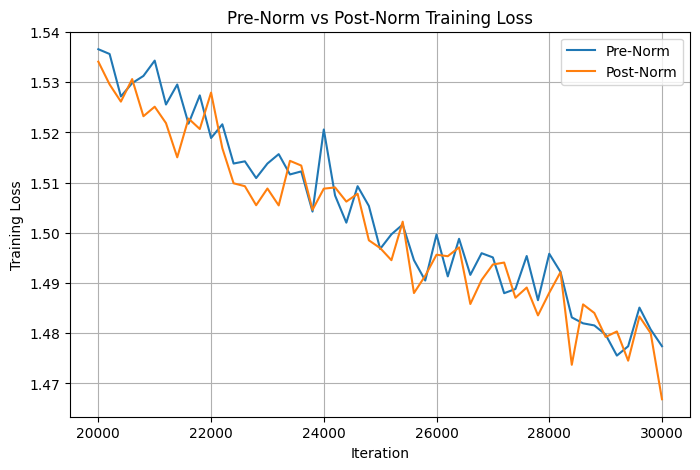

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(pre_stats["eval_steps"][100:], pre_stats["train_curve"][100:], label="Pre-Norm")
plt.plot(post_stats["eval_steps"][100:], post_stats["train_curve"][100:], label="Post-Norm")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Pre-Norm vs Post-Norm Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### 3.B.2

- Both of them are converging at the same rate. There is no clear distinction on which ablation converges faster.

- Finally Post-Norm achieves a lower loss, but the difference with the Pre-Norm loss is extremely small (1.4669 vs 1.4774). 

- No, neither of the ablation show any huge spike in training. On zooming we can see small spikes but those can be attributed to the batch differences. 

In [5]:
# ============================================================
# CELL 5: 3B.3 Text generation
# ============================================================
def generate(model, prompt, max_len=200, temperature=1.0):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    generated = ids.clone()

    with torch.no_grad():
        for _ in range(max_len):
            idx_cond = generated[:, -model.context_len:]
            logits, _ = model(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_id], dim=1)

    return decode(generated[0].tolist())


best_model = pre_stats["model"]

out_t1 = generate(best_model, prompt="The hero", max_len=200, temperature=1.0)
out_t02 = generate(best_model, prompt="The hero", max_len=200, temperature=0.2)
out_t15 = generate(best_model, prompt="The hero", max_len=200, temperature=1.5)

print("===== T = 1.0 =====")
print(out_t1)
print()
print("===== T = 0.2 =====")
print(out_t02)
print()
print("===== T = 1.5 =====")
print(out_t15)

===== T = 1.0 =====
The herous.
    O't is teddest will thou
    Much the was body be in Would That any our day of do he commance
    And a hands pray to heart, such the Taim all,
    To the is bired in a pray tussuriain; name t

===== T = 0.2 =====
The herour of the be so such the shall man the stand to me the fair the words and the man to me the man the counter.
                                                                                           

===== T = 1.5 =====
The herost
    dractaim From form aclwaotys.uve nog.
  RO, JIARD BALPA. We'll by to og
    Storale Confi.

  Gen. Her Cap.
  QUEENS. Is. Sir.
  YORK2. Liver's thouse of Shinch'd puttifer thy have; a. He walis


### 3.B.3

With an increase in temperature the probability distribution becomes more evenly distributed as the individual exponent terms decreases in value both in numerator and denominator and the score for each token thus decreases. Each score is a fraction, and in a fraction, increasing the numerator and denominator usually increases the score and vice versa. With equal score or probability at higher temperature the model has more candidate vocab space for its next token generation and it can be creative with the output. With lower temperature, the scores are unevnly distributed and higher for 1/2 tokens who are more deterministically outputted.

In above cells we can see how t=0.2 is very conservative, it outputs properly sequenced correctly characters, however does not generate the writing style of shakespeare. With t=1.0 we can see the structure of the writing is generated at the cost of some mispronounced words. Whereas at t=1.5 we can see the model outputs the structure but the words are extremely gibberish. 

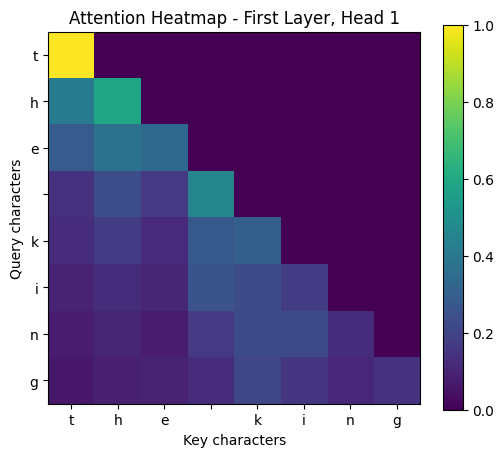

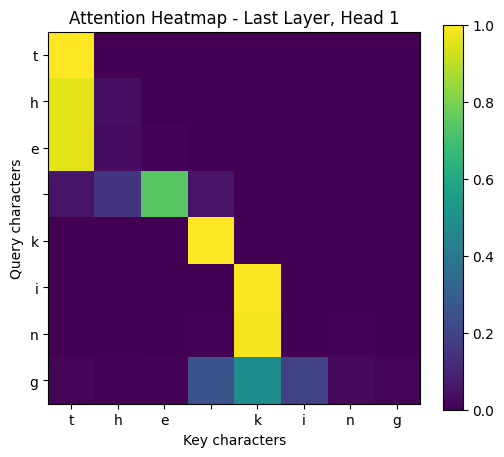

In [6]:
# ============================================================
# CELL 6: 3B.4 Attention visualization
# ============================================================
def plot_attention_heatmap(attn_matrix, tokens, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(attn_matrix, cmap="viridis")
    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key characters")
    plt.ylabel("Query characters")
    plt.title(title)
    plt.colorbar()
    plt.show()


sample_text = "the king"
sample_ids = torch.tensor(encode(sample_text), dtype=torch.long, device=device).unsqueeze(0)

best_model.eval()
with torch.no_grad():
    _ = best_model(sample_ids)

first_layer_attn = best_model.blocks[0].last_attn[0, 0].numpy()
last_layer_attn = best_model.blocks[-1].last_attn[0, 0].numpy()

tokens = list(sample_text)

plot_attention_heatmap(
    first_layer_attn,
    tokens,
    "Attention Heatmap - First Layer, Head 1"
)

plot_attention_heatmap(
    last_layer_attn,
    tokens,
    "Attention Heatmap - Last Layer, Head 1"
)

### 3.B.4.c

No it is the reverse. the earlier layers are more global than the later layers. In the earlier layers the attention scores are distribtued evenly across the tokens whereas in the later layers, higher scores are provided to nearby tokens. The earlier layers might be attending to each token to understand the tokens whereas the later layers are semantically refined as they have to be prepared for next token generation.